In [ ]:
import numpy as np
import os 
from glob import glob
overlap_list = open("assets/gcd_image_stats/has_overlap_list.txt", "r").readlines()
overlap_list = [os.path.basename(line.strip()).replace("_texture.hdf5", "") for line in overlap_list]
oversize_list = open("assets/gcd_image_stats/oversize_list.txt", "r").readlines()
oversize_list = [os.path.basename(line.strip()).replace("_texture.hdf5", "") for line in oversize_list]
saved_folder = "/orion/u/w4756677/garment/gcdv2/gcdv2_images"
folders = glob(os.path.join(saved_folder, "*"))

3392


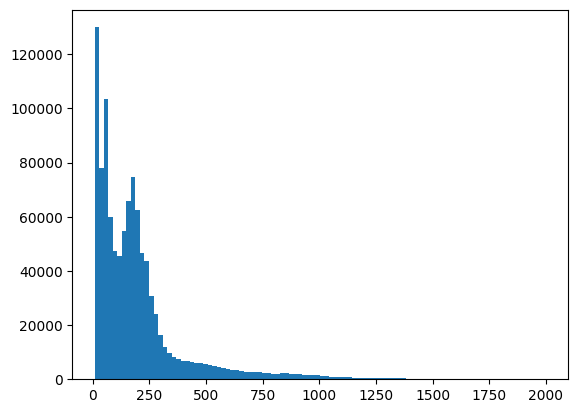

In [6]:
import os 
file = "/orion/u/w4756677/garment/InteractGarment/external/GarmentCode/total_count.txt"
lines = open(file, "r").readlines()
n_edge_list = []
filtered_data_list = []
for line in lines:
    name = line.split()[0]
    words = line.split()[1:]
    words = list(map(int, words))
    if any([w > 2000 for w in words]):
        filtered_data_list.append(name)
        continue
    n_edge_list.extend(words)
print(len(filtered_data_list))
import matplotlib.pyplot as plt 
plt.hist(n_edge_list, bins=100)
plt.show()

9588


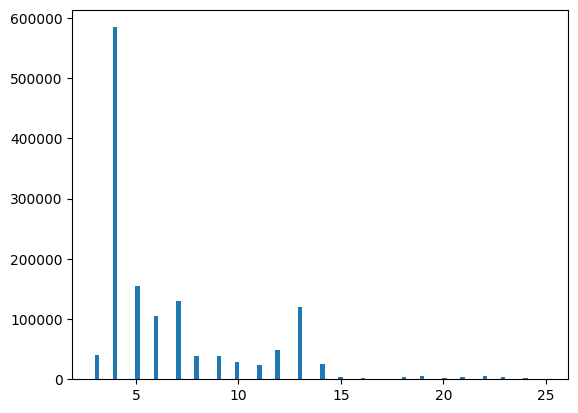

In [7]:
import os 
file = "/orion/u/w4756677/garment/InteractGarment/external/GarmentCode/n_edge_list.txt"
lines = open(file, "r").readlines()
n_edge_list = []
for line in lines:
    name = line.split()[0].split("/")[-2]
    words = line.split()[1:]
    words = list(map(int, words))
    if any([w > 25 for w in words]):
        filtered_data_list.append(name)
        continue
    n_edge_list.extend(words)
print(len(filtered_data_list))
import matplotlib.pyplot as plt 
plt.hist(n_edge_list, bins=100)
plt.show()

In [10]:
print(filtered_data_list)

['rand_UKGS9Y7ZMI237', 'rand_3LG828SC3G276', 'rand_GN2RQF7PVP2849', 'rand_GSKUPHQ62J2447', 'rand_RCGMGBM7O42545', 'rand_F5HGYJ1S0Z166', 'rand_PY8JLO3KXH200', 'rand_YWCGIBQ8I1237', 'rand_WY005G4YQ02827', 'rand_XNAZES9968171', 'rand_I3FRFHW7WY194', 'rand_LAAEI21Q9L173', 'rand_MZ0O4HOPVH173', 'rand_WSTN7NJ15S121', 'rand_VIGSQLN6U1179', 'rand_MIDLG3RYSC137', 'rand_KTEHY317IR2457', 'rand_RKZJFGM6YZ257', 'rand_P662L1GOXN247', 'rand_3EZPSPW01L293', 'rand_PNRHFHHWJH3174', 'rand_ORM9D8DKEA168', 'rand_99YLZZGB6N140', 'rand_ZZW75HN2WR162', 'rand_ASM5ZYGNL2161', 'rand_OIU1FCDGUT222', 'rand_7JN56NJMLB213', 'rand_KSM07C7ZAL261', 'rand_7JY8IYLIMM170', 'rand_PS7BWE1KWA175', 'rand_2Q5NOJWHXU166', 'rand_3EIFQ1RIIR3409', 'rand_NYWDOYQD0T161', 'rand_ZA8H8499TM267', 'rand_YWE0X3EIV3200', 'rand_7Y47EBV2S6216', 'rand_1XT1TOWO9V203', 'rand_6H6HXXEJJI279', 'rand_XXQ2HGZ24T168', 'rand_HB77GR2S0Z157', 'rand_4DG58RTJ23167', 'rand_BW7F74Q3LR122', 'rand_2LBB2XW4R7272', 'rand_83XU8JBZK9192', 'rand_6OBBWFBMPI183', 'r

In [ ]:
data_list = "/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v3.txt"
data_list = open(data_list, "r").readlines()
keep_data_list = []
for data_path in data_list:
    data_name = data_path.split("/")[-2]
    if data_name in filtered_data_list:
        continue
    keep_data_list.append(data_path)
print(len(keep_data_list), len(data_list))

101481 106539


In [ ]:
data_list = open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v3_edge_filtered.txt", "r").readlines()
train_ratio = 0.95
import random 
random.shuffle(data_list)
train_data = data_list[:int(len(data_list)*train_ratio)]
test_data = data_list[int(len(data_list)*train_ratio):]
with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v3_edge_train.txt", "w") as f:
    for line in train_data:
        f.write(line)
with open("/orion/u/w4756677/garment/InteractGarment/src/assets/garment_particle_v3_edge_test.txt", "w") as f:
    for line in test_data:
        f.write(line)

In [6]:
import numpy as np
import os 
from glob import glob
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
saved_folder = "/miele/data/gcd/gcdv2_images"
folders = glob(os.path.join(saved_folder, "*"))

def get_margins(mask: np.ndarray):
    # Ensure binary
    mask = mask.astype(bool)
    
    # Sum along rows and columns to find non-zero regions
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    
    # Find top and bottom indices
    top = np.argmax(rows)
    bottom = len(rows) - 1 - np.argmax(rows[::-1])
    
    # Find left and right indices
    left = np.argmax(cols)
    right = len(cols) - 1 - np.argmax(cols[::-1])
    
    # Margins are distances from image borders
    top_margin = top
    bottom_margin = mask.shape[0] - 1 - bottom
    left_margin = left
    right_margin = mask.shape[1] - 1 - right
    
    return left_margin, right_margin, top_margin, bottom_margin

left_margins, right_margins, top_margins, bottom_margins = [], [], [], []
error_list = []
for folder in tqdm(folders):
    _left_margins, _right_margins, _top_margins, _bottom_margins = [], [], [], []
    if not os.path.exists(os.path.join(folder, "front_1024.png")) or not os.path.exists(os.path.join(folder, "back_1024.png")):
        error_list.append(folder)
        continue
    for img_file in ["front_1024.png", "back_1024.png"]:
        
        img = cv2.imread(os.path.join(folder, img_file), cv2.IMREAD_UNCHANGED)
        
        empty_mask = img[...,3] > 0.5
        left_margin, right_margin, top_margin, bottom_margin = get_margins(empty_mask)
        _left_margins.append(left_margin)
        _right_margins.append(right_margin)
        _top_margins.append(top_margin)
        _bottom_margins.append(bottom_margin)
    
    left_margins.append(min(_left_margins))
    right_margins.append(min(_right_margins))
    top_margins.append(min(_top_margins))
    bottom_margins.append(min(_bottom_margins))

# import shutil
# for folder in to_delete:
#     try:
#         shutil.rmtree(folder)
#     except:
#         pass

  0%|          | 4/35283 [00:00<18:57, 31.02it/s]

0
21417


In [2]:
import scipy, einops, skimage
def downsample_omg(omg, factor=16, anti_aliasing=False, visualize=False):
    """ downsample omg with edge snapping
    Args:
        omg: np.ndarray, (H, W, 4), omage tensor
        factor: int, downsample factor
        anti_aliasing: bool, whether to use anti_aliasing
        visualize: bool, whether to visualize the result
    Returns:
        dict, containing 'omg_down_star', 'omg_down', 'sov', 'edge_occ_down'
        'omg_down_star': np.ndarray, downsampled omg with edge snapping
        'omg_down': np.ndarray, downsampled omg without edge snapping
        'sov': np.ndarray, occupancy map with snapped boundaries highlighted
        'edge_occ_down': np.ndarray, edge occupancy map
    """
    # assuming omg is 1024 x 1024
    occ = omg[...,3] > 0.5
    print(occ.sum())
    eroded_mask = scipy.ndimage.binary_erosion(occ, structure=np.ones((3,3))) # sqaure strucure is needed to get the corners
    edge_occ = ~eroded_mask & occ
    edge_omg = omg.copy()
    edge_omg[edge_occ==0] = -1.
    
    edge_occ_patches = einops.rearrange(edge_occ, '(h1 h2) (w1 w2) -> h1 w1 h2 w2', h2=factor, w2=factor)
    edge_occ_down = edge_occ_patches.max(axis=-1).max(axis=-1)
    eod_0_count  = (edge_occ_patches==0).sum(axis=-1).sum(axis=-1)
    eod_1_count  = (edge_occ_patches==1).sum(axis=-1).sum(axis=-1)
    edge_omg_patches = einops.rearrange(edge_omg, '(h1 h2) (w1 w2) c-> h1 w1 h2 w2 c', h2=factor, w2=factor)
    edge_omg_down = edge_omg_patches.sum(axis=-2).sum(axis=-2) + eod_0_count[...,None]
    edge_omg_down = np.divide(edge_omg_down, eod_1_count[...,None], out=np.zeros_like(edge_omg_down), where=eod_1_count[...,None]!=0)

    omg_down = skimage.transform.resize(omg, (omg.shape[0]//factor,)*2, order=0, preserve_range=False, anti_aliasing=anti_aliasing)
    
    omg_down_star = edge_omg_down * (edge_occ_down[...,None]) + omg_down * (1-edge_occ_down[...,None])
    star_occ = (omg_down[...,3] >= .5) | edge_occ_down
    
    sov = (omg_down[...,3] >= .5) # for visualizaton
    sov = sov * .5 + edge_occ_down.astype(float)
    sov[sov>=1.] = 1.


    return dict(omg_down_star=omg_down_star, omg_down=omg_down,
            sov=sov, edge_occ_down=edge_occ_down, edge_occ=edge_occ, star_occ=star_occ)

96226


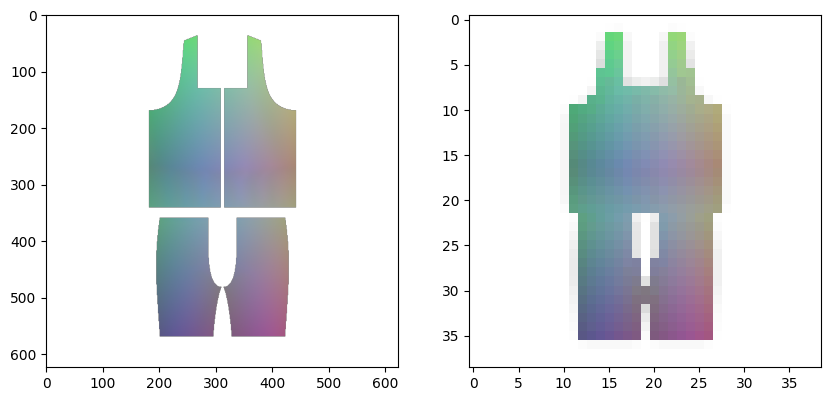

103802


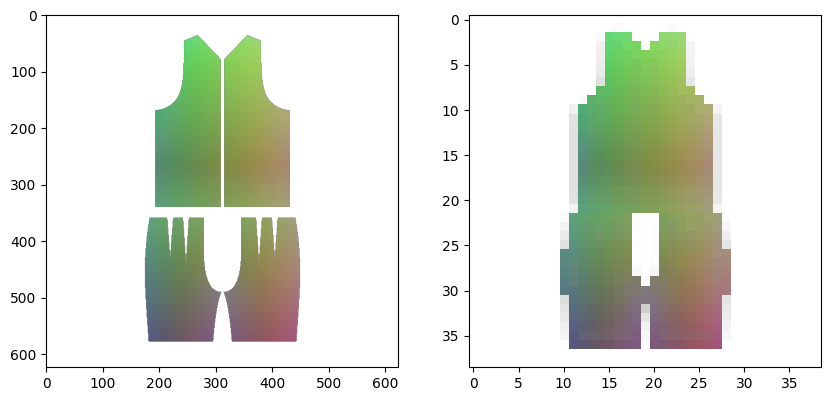

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob

saved_folder = "/miele/data/gcd/gcdv2_images_cutout"
folders = glob(os.path.join(saved_folder, "*"))

for folder in folders[:1]:
    for img_file in ["front_1024.png", "back_1024.png"]:
        img = cv2.imread(os.path.join(folder, img_file), cv2.IMREAD_UNCHANGED)
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA) / 255.0
        downsampled_img = cv2.resize(img, (64, 64))
        # downsampled_img = downsample_omg(img, factor=16, anti_aliasing=True, visualize=False)
        # Convert from float64 to float32 before color conversion
        # img_float32 = downsampled_img["omg_down_star"].astype(np.float32)
        # Scale to 0-255 range for BGR conversion
        img_float32 = (img_float32 * 255).astype(np.uint8)
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img)
        ax[1].imshow(img_float32)
        plt.show()



In [44]:
def meshing_uv_map(occupancy):
    occ = occupancy.astype(bool)
    pixel_index = np.arange(occ.size).reshape(occ.shape)

    # Determine triangles' vertices
    is_tri_vert = occ & np.roll(occ, shift=-1, axis=0) & np.roll(occ, shift=-1, axis=1)
    verta = pixel_index
    vertb = np.roll(pixel_index, shift=-1, axis=1)
    vertc = np.roll(pixel_index, shift=-1, axis=0)
    face0 = np.stack([verta[is_tri_vert], vertb[is_tri_vert], vertc[is_tri_vert]], axis=1)
    
    # Determine the second set of triangles' vertices
    is_tri_vert = occ & np.roll(occ, shift=1, axis=0) & np.roll(occ, shift=1, axis=1)
    verta = pixel_index
    vertb = np.roll(pixel_index, shift=1, axis=1)
    vertc = np.roll(pixel_index, shift=1, axis=0)
    face1 = np.stack([verta[is_tri_vert], vertb[is_tri_vert], vertc[is_tri_vert]], axis=1)
    
    # Combine the two sets of faces
    face = np.concatenate([face0, face1], axis=0)

    return face
def meshing_objamage(img, prune_verts=True):
    """ Turn an omage into a mesh.
    Args:
        omage: dict, containing 'position', 'occupancy', 'objnormal'.
        return_uv: bool, whether to return uv as well.
        prune_verts: bool, whether to remove unused vertices to reduce size.
    """
    occ = np.any(img != 0, axis=-1)
    vert   = img[..., :3]
    vert         = vert.reshape(-1, 3)
    
    face = meshing_uv_map(occ)
    if prune_verts:
        vert, face, _ = prune_unused_vertices(vert, face)
    print(vert.shape, face.shape, face.max())
    return vert, face
    
def prune_unused_vertices(vert, face):
    # Identify all unique vertex indices used in face
    unique_vert_ind = np.unique(face)
    mapper = np.zeros(vert.shape[0], dtype=int)
    mapper[unique_vert_ind] = np.arange(unique_vert_ind.shape[0])
    new_face = mapper[face]
    # Create the new vertices array using only the used vertices
    new_vert = vert[unique_vert_ind]
    
    return new_vert, new_face, unique_vert_ind

all_verts = []
all_faces = []
face_offset = 0
for img_file in ["front_downsampled.png", "back_downsampled.png"]:
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    vert, face = meshing_objamage(img)
    all_verts.append(vert)
    all_faces.append(face + face_offset)
    face_offset += vert.shape[0]
all_verts = np.concatenate(all_verts, axis=0)
all_faces = np.concatenate(all_faces, axis=0)
print(all_verts)
import trimesh
mesh = trimesh.Trimesh(all_verts, all_faces)
print(mesh.vertices.shape, mesh.faces.shape)
mesh.export("mesh.ply")


(2317, 3) (4306, 3) 2316
(2400, 3) (4406, 3) 2399
[[0.         0.00392157 0.        ]
 [0.09411765 0.51372549 0.19607843]
 [0.08627451 0.50980392 0.19607843]
 ...
 [0.26666667 0.98823529 0.18431373]
 [0.25882353 0.99215686 0.18431373]
 [0.         0.00784314 0.        ]]
(4126, 3) (8712, 3)


b'ply\nformat binary_little_endian 1.0\ncomment https://github.com/mikedh/trimesh\nelement vertex 4126\nproperty float x\nproperty float y\nproperty float z\nelement face 8712\nproperty list uchar int vertex_indices\nend_header\n\x00\x00\x00\x00\x81\x80\x80;\x00\x00\x00\x00\xc1\xc0\xc0=\x84\x83\x03?\xc9\xc8H>\xb1\xb0\xb0=\x83\x82\x02?\xc9\xc8H>\xa1\xa0\xa0=\x84\x83\x03?\xd1\xd0P>\x99\x98\x98=\x83\x82\x02?\xdd\xdc\\>\xa1\xa0\xa0=\x83\x82\x02?\xe5\xe4d>\xb9\xb8\xb8=\x83\x82\x02?\xe9\xe8h>\xc9\xc8\xc8=\x82\x81\x01?\xed\xecl>\xd9\xd8\xd8=\x82\x81\x01?\xf5\xf4t>\xe1\xe0\xe0=\x82\x81\x01?\x81\x80\x80>\xe9\xe8\xe8=\x82\x81\x01?\x87\x86\x86>\xe9\xe8\xe8=\x82\x81\x01?\x8b\x8a\x8a>\xf1\xf0\xf0=\x83\x82\x02?\x91\x90\x90>\x81\x80\x00>\x82\x81\x01?\x95\x94\x94>\x8d\x8c\x0c>\x82\x81\x01?\x97\x96\x96>\x95\x94\x14>\x82\x81\x01?\x95\x94\x94>\xa1\xa0 >\x81\x80\x00?\x93\x92\x92>\xad\xac,>\x81\x80\x00?\x93\x92\x92>\xb5\xb44>\x81\x80\x00?\x95\x94\x94>\xbd\xbc<>\x81\x80\x00?\x99\x98\x98>\xc5\xc4D>\x81\x80\x

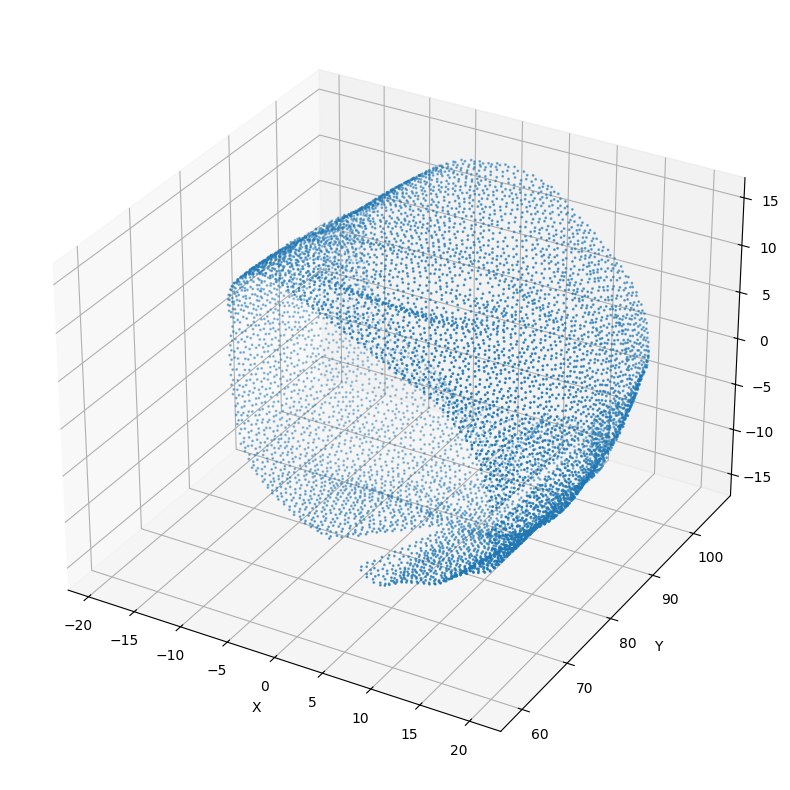

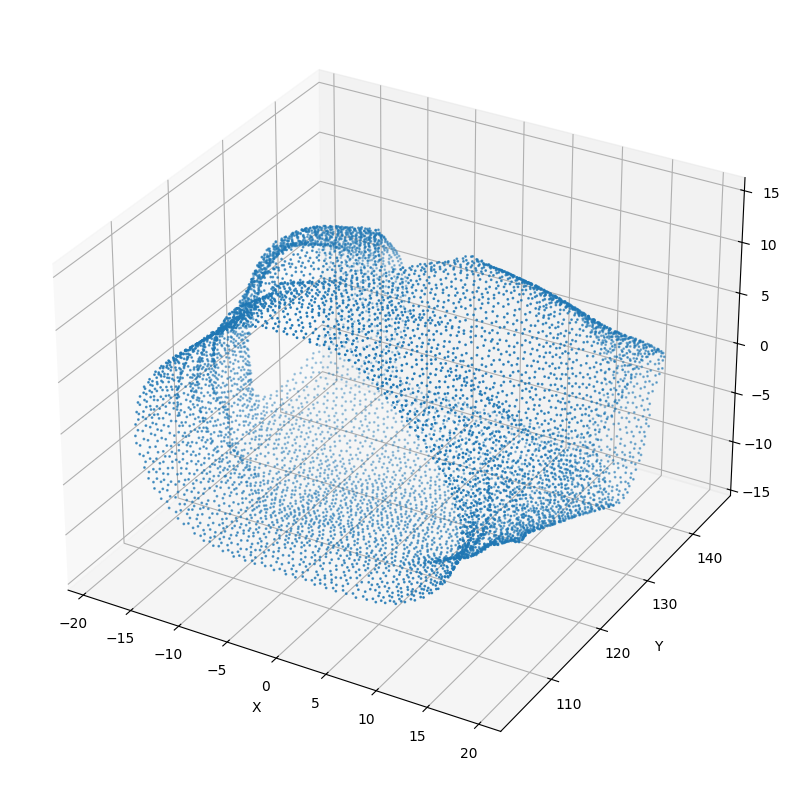

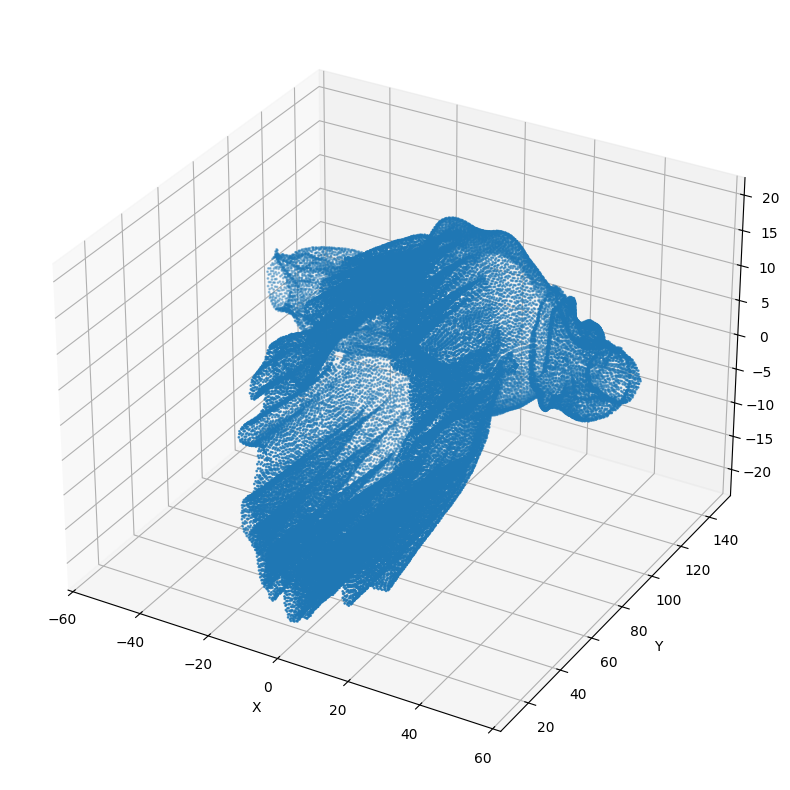

In [10]:


for texture_file in folders:
    texture = np.load(texture_file)
    front_panel = texture["front_panel"]
    front_pcd = front_panel[:, :3]
    back_panel = texture["back_panel"]
    back_pcd = back_panel[:, :3]
    pcd = np.concatenate([front_pcd, back_pcd], axis=0)
    pcd = pcd.reshape(-1, 3)
    pcd = pcd.astype(np.float32)
    
    # Create 3D scatter plot
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pcd[:, 0], pcd[:, 1], pcd[:, 2], s=1)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()
    plt.close()

In [ ]:
for source_face in source_mesh.faces:
    target_face = [target2source[i] for i in source_face]
    target_uv = target_mesh.face_uvs[target_face]
    print(target_uv)
    # source_face_verts = source_mesh.vertices[source_face]
    # target_face_verts = target_mesh.vertices[source_face]
    # dist = np.linalg.norm(source_face_verts - target_face_verts, axis=1)
    # min_idx = np.argmin(dist)
    # print(min_idx, dist[min_idx])
    break


TypeError: only integer scalar arrays can be converted to a scalar index